# Clustering

## Cálculo de medidas de distancia

In [2]:
# Conjunto de datos

import pandas as pd
from google.colab import files

uploaded = files.upload()
datos = pd.read_excel("Trabajadores.xlsx")

datos.iloc[:, [0, 2, 7, 11]] = datos.iloc[:, [0, 2, 7, 11]].astype("category")

datos["Escolaridad"] = pd.Categorical(
    datos["Escolaridad"],
    categories=["Técnico", "Pregrado", "Posgrado"],
    ordered=True
)

datos["Estrato"] = datos["Estrato"].astype("string").str.strip()

datos["Estrato"] = datos["Estrato"].replace({
    "1.0": "1",
    "2.0": "2",
    "3.0": "3"
})

datos["Estrato"] = pd.Categorical(
    datos["Estrato"],
    categories=["1", "2", "3", "4+"],
    ordered=True
)

datos["Situación"] = pd.Categorical(
    datos["Situación"],
    categories=["Difícil", "Regular", "Buena"],
    ordered=True
)

print(datos.head())
print(datos.shape)

Saving Trabajadores.xlsx to Trabajadores (1).xlsx
  Sexo  Edad  Estado  Hijos Escolaridad Estrato  Ingresos Ayuda  Dependen  \
0    F    45  Casado      2    Posgrado      4+     8.800    No         3   
1    M    36  Casado      2    Pregrado       3     5.920    No         1   
2    M    61  Casado      3     Técnico       2     2.256    Sí         2   
3    F    40   Viudo      2    Posgrado       2     5.706    No         2   
4    F    49  Casado      3    Posgrado      4+     9.450    Sí         1   

   Egresos Situación      Créditos  Conocimiento  
0    8.410     Buena  Sin Créditos         0.249  
1    3.915     Buena      Vigentes         0.491  
2    2.390   Difícil      Vigentes         0.449  
3    3.480     Buena      Vigentes         0.506  
4    2.900     Buena      Vigentes         0.675  
(168, 13)


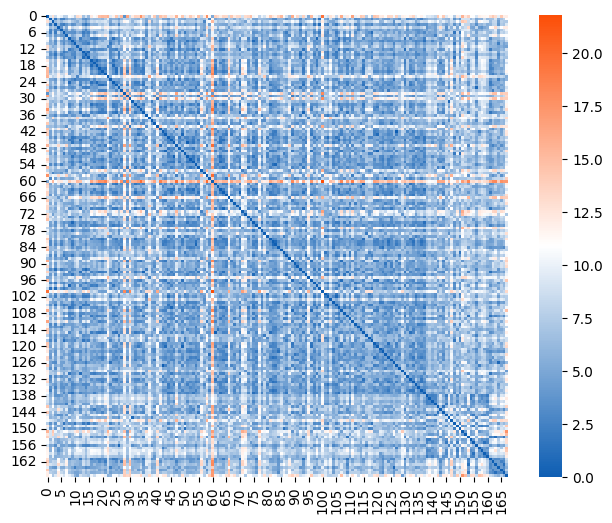

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import LinearSegmentedColormap

# Ilustrando el cálculo de distancias
# para diferentes tipos de variables

# Distancia para variables númericas

# Matriz de distancias - variables numéricas

# Distancia de Manhattan
X = datos.select_dtypes(include="number")
X = (X - X.mean()) / X.std(ddof=1)

D = pd.DataFrame(
    squareform(pdist(X, metric="cityblock")),
    index=datos.index,
    columns=datos.index
)

D

# Gráfico de la matriz de distancias
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["#0e5eb3", "white", "#FC4E07"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(D, cmap=cmap, square=True, cbar=True)
plt.show()

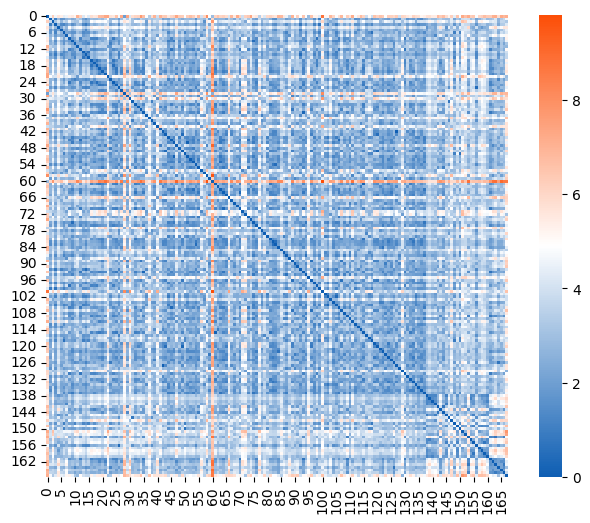

In [4]:
# Distancia Euclidiana
X = datos.select_dtypes(include="number")
X = (X - X.mean()) / X.std(ddof=1)

D = pd.DataFrame(
    squareform(pdist(X, metric="euclidean")),
    index=datos.index,
    columns=datos.index
)

D

# Gráfico de la matriz de distancias
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["#0e5eb3", "white", "#FC4E07"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(D, cmap=cmap, square=True, cbar=True)
plt.show()

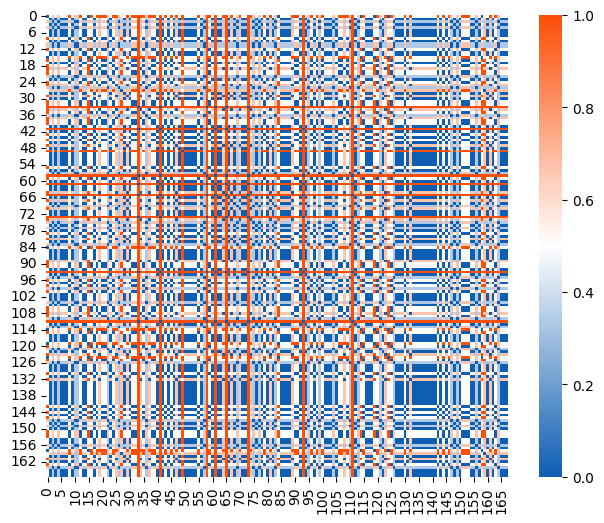

In [5]:
# Distancia para variables binarias

# Distancia de Jaccard
X = datos[["Créditos", "Ayuda", "Hijos"]].copy()

X["Créditos"] = np.where(X["Créditos"] == "Sin Créditos", 0, 1)
X["Ayuda"] = np.where(X["Ayuda"] == "Sí", 1, 0)
X["Hijos"] = np.where(X["Hijos"] > 0, 1, 0)

D = pd.DataFrame(
    squareform(pdist(X.astype(bool), metric="jaccard")),
    index=datos.index,
    columns=datos.index
)

D

# Gráfico de la matriz de distancias
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["#0e5eb3", "white", "#FC4E07"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(D, cmap=cmap, square=True, cbar=True)
plt.show()

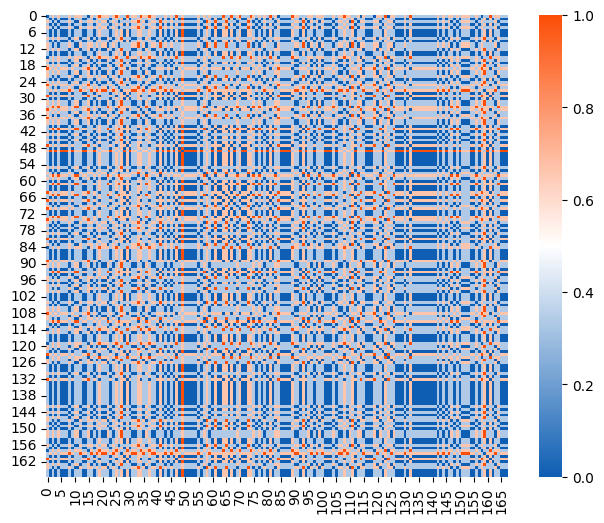

In [7]:
# Distancia de Afinidad
D = pd.DataFrame(
    squareform(pdist(X, metric="hamming")),
    index=datos.index,
    columns=datos.index
)

D

# Gráfico de la matriz de distancias
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["#0e5eb3", "white", "#FC4E07"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(D, cmap=cmap, square=True, cbar=True)
plt.show()

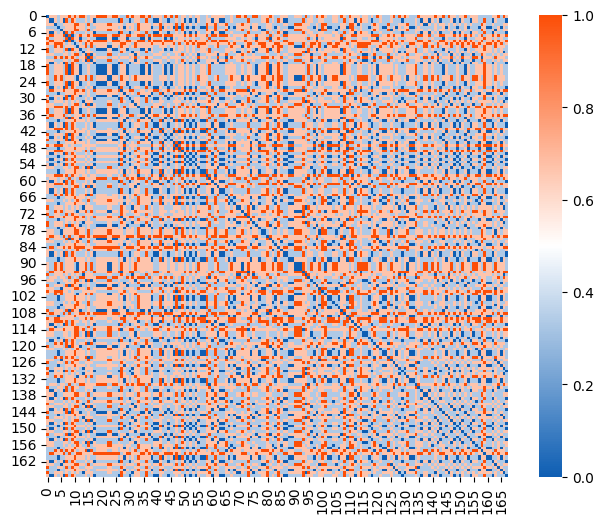

In [10]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import pairwise_distances

# Distancia para variables categóricas

X = datos[["Sexo", "Estado", "Créditos"]].copy()

encoder = OrdinalEncoder()
X_cod = encoder.fit_transform(X)

D = pd.DataFrame(
    pairwise_distances(X_cod, metric="hamming"),
    index=datos.index,
    columns=datos.index
)

D

# Gráfico de la matriz de distancias
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["#0e5eb3", "white", "#FC4E07"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(D, cmap=cmap, square=True, cbar=True)
plt.show()

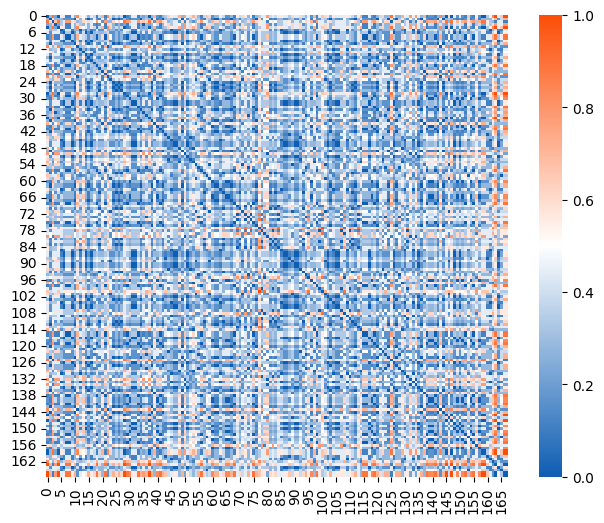

In [11]:
from sklearn.metrics import pairwise_distances

# Distancia para variables ordinales
X = datos[["Escolaridad", "Estrato", "Situación"]].copy()

X["Escolaridad"] = pd.Categorical(
    X["Escolaridad"],
    categories=["Técnico", "Pregrado", "Posgrado"],
    ordered=True
)

X["Estrato"] = pd.Categorical(
    X["Estrato"],
    categories=["1", "2", "3", "4+"],
    ordered=True
)

X["Situación"] = pd.Categorical(
    X["Situación"],
    categories=["Difícil", "Regular", "Buena"],
    ordered=True
)

X_cod = pd.DataFrame({
    "Escolaridad": X["Escolaridad"].cat.codes / 2,
    "Estrato": X["Estrato"].cat.codes / 3,
    "Situación": X["Situación"].cat.codes / 2
}, index=datos.index)

D = pd.DataFrame(
    pairwise_distances(X_cod, metric="manhattan") / X_cod.shape[1],
    index=datos.index,
    columns=datos.index
)

D

# Gráfico de la matriz de distancias
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["#0e5eb3", "white", "#FC4E07"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(D, cmap=cmap, square=True, cbar=True)
plt.show()

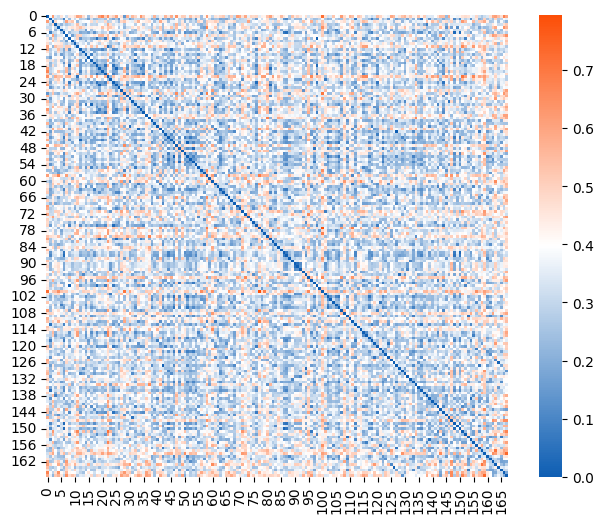

In [13]:
# Distancia para mixtura de variables (Gower)
X = datos.copy()

X["Ayuda"] = np.where(X["Ayuda"] == "Sí", 1, 0)

X["Sexo"] = X["Sexo"].astype("category")
X["Estado"] = X["Estado"].astype("category")
X["Créditos"] = X["Créditos"].astype("category")

X["Escolaridad"] = pd.Categorical(
    X["Escolaridad"],
    categories=["Técnico", "Pregrado", "Posgrado"],
    ordered=True
)

X["Estrato"] = X["Estrato"].astype("string").str.strip().replace({
    "1.0": "1",
    "2.0": "2",
    "3.0": "3"
})

X["Estrato"] = pd.Categorical(
    X["Estrato"],
    categories=["1", "2", "3", "4+"],
    ordered=True
)

X["Situación"] = pd.Categorical(
    X["Situación"],
    categories=["Difícil", "Regular", "Buena"],
    ordered=True
)

asymm_vars = ["Ayuda"]
factor_vars = ["Sexo", "Estado", "Créditos"]
ordered_vars = ["Escolaridad", "Estrato", "Situación"]
numeric_vars = [
    col for col in X.columns
    if col not in asymm_vars + factor_vars + ordered_vars
    and pd.api.types.is_numeric_dtype(X[col])
]

partes = []
pesos = []

X_num = X[numeric_vars].astype(float)
rango = X_num.max() - X_num.min()
X_num = (X_num - X_num.min()) / rango

A = X_num.to_numpy()
partes.append(np.abs(A[:, None, :] - A[None, :, :]))
pesos.append(np.ones_like(partes[-1]))

A = X[factor_vars].astype(str).to_numpy()
partes.append((A[:, None, :] != A[None, :, :]).astype(float))
pesos.append(np.ones_like(partes[-1]))

X_ord = pd.DataFrame(index=X.index)

X_ord["Escolaridad"] = X["Escolaridad"].cat.codes / 2
X_ord["Estrato"] = X["Estrato"].cat.codes / 3
X_ord["Situación"] = X["Situación"].cat.codes / 2

A = X_ord.to_numpy()
partes.append(np.abs(A[:, None, :] - A[None, :, :]))
pesos.append(np.ones_like(partes[-1]))

A = X[asymm_vars].to_numpy()
dist_asymm = (A[:, None, :] != A[None, :, :]).astype(float)
peso_asymm = ~((A[:, None, :] == 0) & (A[None, :, :] == 0))

partes.append(dist_asymm)
pesos.append(peso_asymm.astype(float))

num = np.concatenate(partes, axis=2)
w = np.concatenate(pesos, axis=2)

D_array = (num * w).sum(axis=2) / w.sum(axis=2)
np.fill_diagonal(D_array, 0)

D = pd.DataFrame(
    D_array,
    index=datos.index,
    columns=datos.index
)

D

# Gráfico de la matriz de distancias
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["#0e5eb3", "white", "#FC4E07"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(D, cmap=cmap, square=True, cbar=True)
plt.show()